# 03 — Feature Engineering
Build RFM, behavioural, and cohort features. Validate before porting to `features/`.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from pathlib import Path

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Load cleaned data

In [2]:
df = pd.read_parquet("../data/interim/cleaned.parquet")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(f"Shape: {df.shape}")
df.head()


Shape: (385081, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. RFM features

In [3]:
snapshot_date = df["InvoiceDate"].max() + timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = df.groupby("CustomerID").agg(
    Recency   = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("InvoiceNo","nunique"),
    Monetary  = ("Revenue","sum"),
).reset_index()

rfm.describe()


Snapshot date: 2011-12-10


,Recency,Frequency,Monetary
count,4290.000000,4290.000000,4290.000000
mean,92.574592,4.191142,1607.563469
std,99.993918,7.465179,4815.340647
min,1.000000,1.000000,2.900000
25%,18.000000,1.000000,287.962500
50%,51.000000,2.000000,632.060000
75%,143.000000,5.000000,1540.470000
max,374.000000,205.000000,158967.800000


## 4. RFM distributions

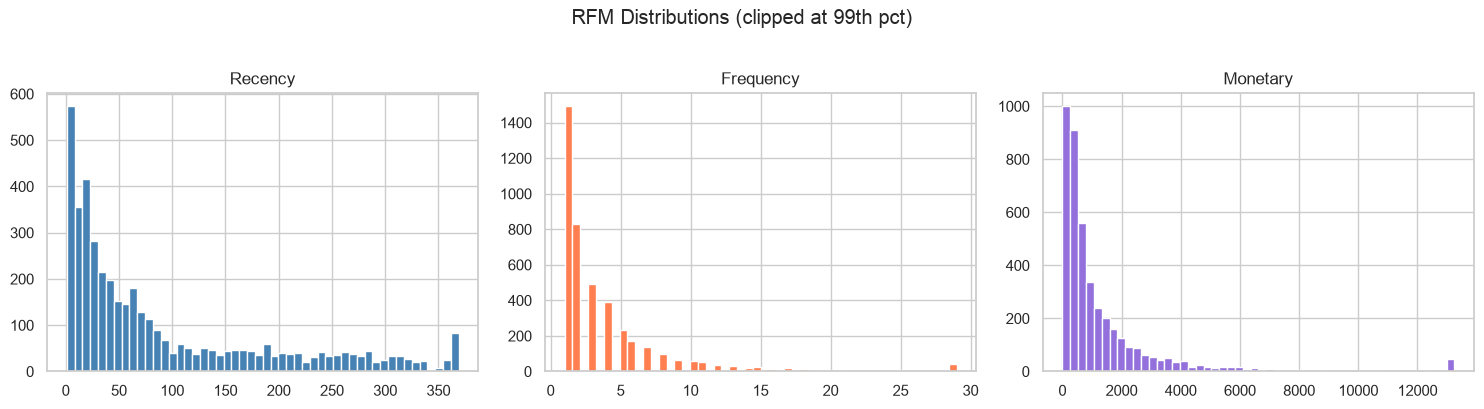

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["Recency","Frequency","Monetary"], ["steelblue","coral","mediumpurple"]):
    rfm[col].clip(upper=rfm[col].quantile(0.99)).hist(bins=50, ax=ax, color=color, edgecolor="white")
    ax.set_title(col)
plt.suptitle("RFM Distributions (clipped at 99th pct)", y=1.02)
plt.tight_layout()
plt.show()


## 5. Log-transform skewed columns

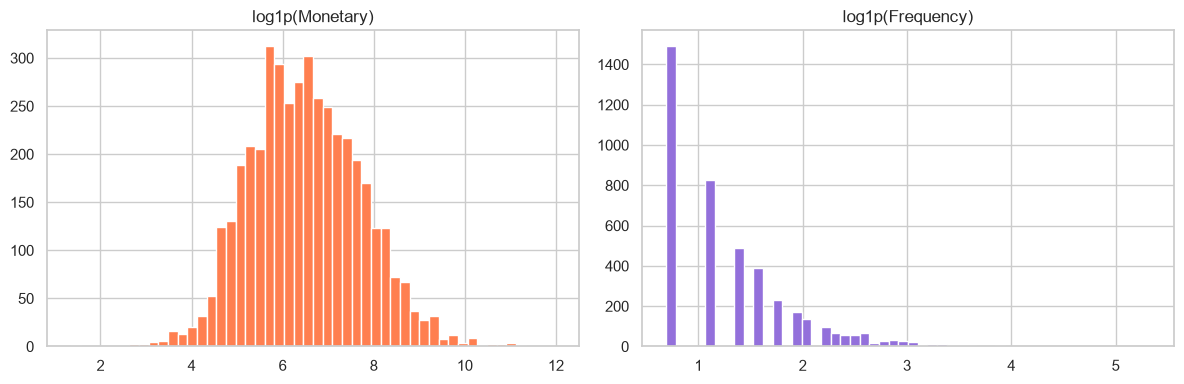

In [5]:
rfm["Log_Monetary"]  = np.log1p(rfm["Monetary"])
rfm["Log_Frequency"] = np.log1p(rfm["Frequency"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rfm["Log_Monetary"].hist(bins=50, ax=axes[0], color="coral", edgecolor="white")
axes[0].set_title("log1p(Monetary)")
rfm["Log_Frequency"].hist(bins=50, ax=axes[1], color="mediumpurple", edgecolor="white")
axes[1].set_title("log1p(Frequency)")
plt.tight_layout()
plt.show()

## 6. Behavioural features

In [8]:
# Average order value + spend volatility
aov = (
    df.groupby(["CustomerID","InvoiceNo"])["Revenue"].sum()
    .reset_index()
    .groupby("CustomerID")["Revenue"]
    .agg(AOV="mean", SpendStd="std")
    .reset_index()
)

# Temporal patterns
temporal = df.groupby("CustomerID").agg(
    PreferredDayOfWeek = ("InvoiceDate", lambda x: x.dt.dayofweek.mode()[0]),
    WeekendRatio       = ("InvoiceDate", lambda x: (x.dt.dayofweek >= 5).mean()),
    PreferredHour      = ("InvoiceDate", lambda x: x.dt.hour.mode()[0]),
).reset_index()

# Product diversity
product = df.groupby("CustomerID").agg(
    UniqueSKUs     = ("StockCode", "nunique"),
    TotalItems     = ("Quantity",  "sum"),
    RepeatSKURatio = ("StockCode", lambda x: x.duplicated().mean()),
).reset_index()

# Inter-purchase gap
gaps = (
    df.groupby(["CustomerID","InvoiceNo"])["InvoiceDate"].min()
    .reset_index()
    .sort_values(["CustomerID","InvoiceDate"])
    .groupby("CustomerID")["InvoiceDate"]
    .apply(lambda x: x.diff().dt.days.dropna())
    .reset_index(level=0)
    .rename(columns={"InvoiceDate": "GapDays"})
    .groupby("CustomerID")["GapDays"]
    .agg(AvgGap="mean", StdGap="std")
    .reset_index()
)

# Return rate
#We cleaned the data in the previous notebook, so we can use the raw data to calculate return rate.
RAW = Path("../data/raw/online_retail.csv")
df_raw = pd.read_csv(RAW,encoding='latin1')
df_raw["CustomerID"] = df_raw["CustomerID"].dropna()
df_raw = df_raw.dropna(subset=["CustomerID"])
df_raw["CustomerID"] = df_raw["CustomerID"].astype(int).astype(str)

returns = (
    df_raw.assign(
        IsCancelled=df_raw["InvoiceNo"].astype(str).str.startswith("C")
    )
    .groupby("CustomerID")
    .agg(
        TotalOrders=("InvoiceNo", "nunique"),
        CancelledOrders=("IsCancelled", "sum")
    )
    .reset_index()
)

returns["ReturnRate"] = (
    returns["CancelledOrders"] / returns["TotalOrders"]
)

returns = returns[["CustomerID", "ReturnRate"]]

behavioural = (
    aov
    .merge(temporal, on="CustomerID", how="left")
    .merge(product,  on="CustomerID", how="left")
    .merge(gaps,     on="CustomerID", how="left")
    .merge(returns,  on="CustomerID", how="left")
)

print(f"Behavioural features shape: {behavioural.shape}")
behavioural.head()

Behavioural features shape: (4290, 12)


,CustomerID,AOV,SpendStd,PreferredDayOfWeek,WeekendRatio,PreferredHour,UniqueSKUs,TotalItems,RepeatSKURatio,AvgGap,StdGap,ReturnRate
0,12347,580.057143,351.455168,1,0.000000,14,102,2218,0.436464,60.333333,18.478817,0.000000
1,12348,296.670000,225.294269,3,0.095238,19,15,1468,0.285714,94.000000,70.149840,0.000000
2,12349,1353.800000,NaN,0,0.000000,9,70,625,0.000000,NaN,NaN,0.000000
3,12350,294.400000,NaN,2,0.000000,16,16,196,0.000000,NaN,NaN,0.000000
4,12352,197.962857,81.916277,1,0.000000,14,57,526,0.259740,43.000000,68.419296,0.909091


## 7. Cohort features

In [9]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

first_purchase = (
    df.groupby("CustomerID")["InvoiceMonth"]
    .min()
    .rename("CohortMonth")
    .reset_index()
)

cohort = df.merge(first_purchase, on="CustomerID")

cohort_feats = cohort.groupby("CustomerID").agg(
    CohortMonth            = ("CohortMonth",   "first"),
    ActiveMonths           = ("InvoiceMonth",  "nunique"),
    DaysSinceFirstPurchase = ("InvoiceDate",   lambda x: (x.max() - x.min()).days),
).reset_index()

cohort_feats["CohortMonth"] = cohort_feats["CohortMonth"].astype(str)
print(f"Cohort features shape: {cohort_feats.shape}")
cohort_feats.head()

Cohort features shape: (4290, 4)


,CustomerID,CohortMonth,ActiveMonths,DaysSinceFirstPurchase
0,12347,2010-12,7,365
1,12348,2010-12,4,282
2,12349,2011-11,1,0
3,12350,2011-02,1,0
4,12352,2011-02,4,260
